# Laboratorio #9 - Teoría de Probabilidades
Integrantes del grupo: Santiago Cordero (Carnet 24472) y Luis Pedro Hernández (Carnet 24337).
Sección: 30

## Etapa 5: Simulación del álbum real

En este laboratorio se usa el álbum real del Mundial 2026 con `N = 980` estampas. Las cinco preguntas que nosotros planteamos son las siguientes:

1. ¿Cuál es el número esperado de sobres necesarios para llenar el álbum si cada sobre tiene 4 estampitas?
2. ¿Cuántos sobres se necesitan para tener al menos el 90% de las estampas si cada sobre ahora trae 5 estampitas?
3. ¿Cuál es la probabilidad de NO completar el álbum con un presupuesto de Q 3,000.00?
4. ¿Cómo cambia el valor esperado de sobres al comprar sobres versus cajas si cada sobre trae 8 estampitas?
5. ¿Cómo cambia el valor esperado del presupuesto con respecto a valores distintos de estampitas por sobre?

In [13]:
import math

import matplotlib.pyplot as plt
import numpy as np

N = 980
S_REAL = 7
PRECIO_SOBRE = 9.50
COSTO_CAJA = 975.00
SOBRES_CAJA = 104
PRESUPUESTO_Q3 = 3000.00
SEED = 2026

# N = 980 hace que llenar el album completo sea mucho mas costoso que en el album reducido.
# Por eso se usan menos repeticiones que en laboratorios anteriores.
R_COMPLETAR = 1_500
R_META_90 = 3_000
R_PRESUPUESTO = 3_000
R_VARIACION = 800

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def numero_teorico_aproximado(n, s):
    """Aproximacion tipo coupon collector: E[sobres] ~= (N / S) * H_N."""
    h_n = sum(1 / j for j in range(1, n + 1))
    return (n / s) * h_n


def sobres_teoricos_para_fraccion(n, s, fraccion):
    """Sobres necesarios para que el valor esperado de distintas alcance cierta fraccion."""
    return math.ceil(math.log(1 - fraccion) / math.log(1 - s / n))


def simular_hasta_meta(n, s, r, seed, fraccion_meta=1.0):
    """Compra sobres hasta alcanzar una fraccion del album o completarlo."""
    rng = np.random.default_rng(seed)
    meta = math.ceil(n * fraccion_meta)
    sobres = np.empty(r, dtype=int)
    repetidas = np.empty(r, dtype=int)

    for i in range(r):
        album = np.zeros(n, dtype=bool)
        distintas = 0
        total_repetidas = 0
        num_sobres = 0

        while distintas < meta:
            sobre = rng.choice(n, size=s, replace=False)
            nuevas_mask = ~album[sobre]
            nuevas = int(nuevas_mask.sum())
            total_repetidas += s - nuevas

            if nuevas > 0:
                album[sobre[nuevas_mask]] = True
                distintas += nuevas

            num_sobres += 1

        sobres[i] = num_sobres
        repetidas[i] = total_repetidas

    return sobres, repetidas


def simular_sobres_fijos(n, s, m, r, seed):
    """Compra exactamente m sobres y reporta si el album se completa."""
    rng = np.random.default_rng(seed)
    completo = np.zeros(r, dtype=bool)
    distintas_finales = np.empty(r, dtype=int)
    repetidas = np.empty(r, dtype=int)

    for i in range(r):
        album = np.zeros(n, dtype=bool)
        distintas = 0
        total_repetidas = 0

        for _ in range(m):
            sobre = rng.choice(n, size=s, replace=False)
            nuevas_mask = ~album[sobre]
            nuevas = int(nuevas_mask.sum())
            total_repetidas += s - nuevas

            if nuevas > 0:
                album[sobre[nuevas_mask]] = True
                distintas += nuevas

        completo[i] = distintas == n
        distintas_finales[i] = distintas
        repetidas[i] = total_repetidas

    return completo, distintas_finales, repetidas


def imprimir_tabla(encabezados, filas):
    """Imprime una tabla simple sin depender de pandas."""
    anchos = [
        max(len(str(encabezados[j])), *(len(str(fila[j])) for fila in filas))
        for j in range(len(encabezados))
    ]
    formato = "  ".join(f"{{:<{ancho}}}" for ancho in anchos)
    print(formato.format(*encabezados))
    print("  ".join("-" * ancho for ancho in anchos))
    for fila in filas:
        print(formato.format(*fila))

## Pregunta 1

¿Cuál es el número esperado de sobres necesarios para llenar el álbum si cada sobre tiene 4 estampitas?

In [3]:
sobres_s4, repetidas_s4 = simular_hasta_meta(
    n=N,
    s=4,
    r=R_COMPLETAR,
    seed=SEED + 4,
    fraccion_meta=1.0,
)

media_s4 = sobres_s4.mean()
aprox_s4 = numero_teorico_aproximado(N, 4)

print("Pregunta 1: llenar el album con 4 estampitas por sobre")
print("-" * 64)
print(f"Numero esperado simulado de sobres: {media_s4:,.2f}")
print(f"Aproximacion teorica (N/S)H_N: {aprox_s4:,.2f}")

Pregunta 1: llenar el album con 4 estampitas por sobre
----------------------------------------------------------------
Numero esperado simulado de sobres: 1,830.88
Aproximacion teorica (N/S)H_N: 1,828.99


### Respuesta 1

Con `S = 4`, el número esperado simulado de sobres necesarios para completar el álbum fue aproximadamente `1830.88` sobres. La aproximación teórica `(N/S)H_N` dio `1828.99`.

## Pregunta 2

¿Cuántos sobres se necesitan para tener al menos el 90% de las estampas si cada sobre ahora trae 5 estampitas?

In [3]:
sobres_90_s5, repetidas_90_s5 = simular_hasta_meta(
    n=N,
    s=5,
    r=R_META_90,
    seed=SEED + 5,
    fraccion_meta=0.90,
)

meta_90 = math.ceil(0.90 * N)
media_90_s5 = sobres_90_s5.mean()
aprox_90_s5 = sobres_teoricos_para_fraccion(N, 5, 0.90)

print("Pregunta 2: alcanzar al menos 90% del album con 5 estampitas por sobre")
print("-" * 76)
print(f"Meta de estampas distintas: {meta_90} de {N}")
print(f"Sobres esperados para llegar a la meta: {media_90_s5:,.2f}")
print(f"Sobres teoricos para que E[distintas] alcance 90%: {aprox_90_s5}")

Pregunta 2: alcanzar al menos 90% del album con 5 estampitas por sobre
----------------------------------------------------------------------------
Meta de estampas distintas: 882 de 980
Sobres esperados para llegar a la meta: 450.08
Sobres teoricos para que E[distintas] alcance 90%: 451


### Respuesta 2

Para alcanzar al menos el 90% del álbum se necesitan `882` estampas distintas. Con `S = 5`, la simulación estimó un promedio de `450.08` sobres. El cálculo teórico para que el valor esperado de estampas distintas alcance el 90% da `451` sobres.

## Pregunta 3

¿Cuál es la probabilidad de NO completar el álbum con un presupuesto de Q 3,000.00?

In [15]:
max_sobres = math.floor(PRESUPUESTO_Q3 / PRECIO_SOBRE)
gasto = max_sobres * PRECIO_SOBRE
sobrante = PRESUPUESTO_Q3 - gasto
estampas_fisicas_max = max_sobres * S_REAL

completo, distintas, repetidas = simular_sobres_fijos(
    n=N,
    s=S_REAL,
    m=max_sobres,
    r=R_PRESUPUESTO,
    seed=SEED + 7,
)

prob_no_completar = 1 - completo.mean()
media_distintas = distintas.mean()

print(f"Pregunta 3: presupuesto fijo de Q {PRESUPUESTO_Q3:,.2f}")
print("-" * 60)
print(f"Sobres que permite el presupuesto: {max_sobres}")
print(f"Estampas fisicas compradas como maximo: {estampas_fisicas_max}")
print(f"Estampas necesarias para completar: {N}")
print(f"Probabilidad estimada de NO completar: {prob_no_completar:.4f} ({prob_no_completar:.2%})")
print(f"Estampas distintas promedio: {media_distintas:,.2f}")

Pregunta 3: presupuesto fijo de Q 3,000.00
------------------------------------------------------------
Sobres que permite el presupuesto: 315
Estampas fisicas compradas como maximo: 2205
Estampas necesarias para completar: 980
Probabilidad estimada de NO completar: 1.0000 (100.00%)
Estampas distintas promedio: 877.40


### Respuesta 3

Con Q `3,000.00` se pueden comprar `315` sobres individuales, lo que equivale a `2,205` estampas físicas.

La probabilidad estimada de NO completar el álbum es `100%`. En la simulación, el promedio fue de `877.40` estampas distintas.

## Pregunta 4

¿Cómo cambia el valor esperado de sobres al comprar sobres versus cajas si cada sobre trae 8 estampitas?

Pregunta 4: sobres sueltos vs cajas con 8 estampitas por sobre
--------------------------------------------------------------------------
Sobres necesarios promedio para completar: 915.16
Aproximacion teorica (N/S)H_N: 914.50
Sobres comprados promedio si solo se compran cajas: 966.44

Estrategia      E[sobres comprados]  E[costo]    E[sobres sobrantes]  E[cajas] 
--------------  -------------------  ----------  -------------------  ---------
Sobres sueltos  915.16               Q 8,694.01  0.00                 No aplica
Cajas de 104    966.44               Q 9,060.35  51.28                9.29     


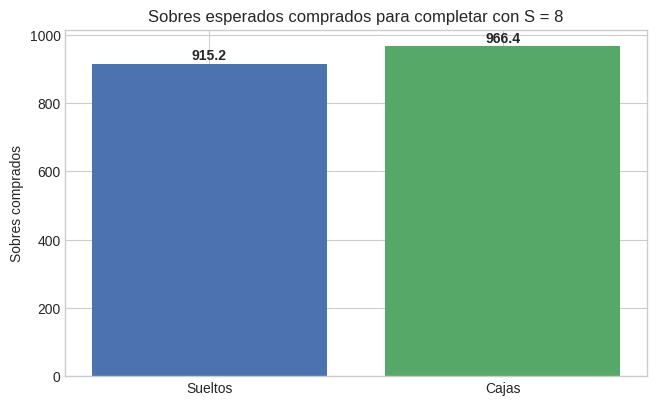

In [6]:
sobres_s8, repetidas_s8 = simular_hasta_meta(
    n=N,
    s=8,
    r=R_COMPLETAR,
    seed=SEED + 8,
    fraccion_meta=1.0,
)

cajas_s8 = np.ceil(sobres_s8 / SOBRES_CAJA).astype(int)
sobres_comprados_caja_s8 = cajas_s8 * SOBRES_CAJA
sobres_sobrantes_caja_s8 = sobres_comprados_caja_s8 - sobres_s8

media_s8 = sobres_s8.mean()
media_sobres_caja_s8 = sobres_comprados_caja_s8.mean()
aprox_s8 = numero_teorico_aproximado(N, 8)

costo_sueltos_s8 = sobres_s8 * PRECIO_SOBRE
costo_cajas_s8 = cajas_s8 * COSTO_CAJA

filas_q4 = [
    [
        "Sobres sueltos",
        f"{sobres_s8.mean():,.2f}",
        f"Q {costo_sueltos_s8.mean():,.2f}",
        "0.00",
        "No aplica",
    ],
    [
        "Cajas de 104",
        f"{sobres_comprados_caja_s8.mean():,.2f}",
        f"Q {costo_cajas_s8.mean():,.2f}",
        f"{sobres_sobrantes_caja_s8.mean():,.2f}",
        f"{cajas_s8.mean():,.2f}",
    ],
]

print("Pregunta 4: sobres sueltos vs cajas con 8 estampitas por sobre")
print("-" * 74)
print(f"Sobres necesarios promedio para completar: {media_s8:,.2f}")
print(f"Aproximacion teorica (N/S)H_N: {aprox_s8:,.2f}")
print(f"Sobres comprados promedio si solo se compran cajas: {media_sobres_caja_s8:,.2f}")
print()
imprimir_tabla(
    ["Estrategia", "E[sobres comprados]", "E[costo]", "E[sobres sobrantes]", "E[cajas]"],
    filas_q4,
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(
    ["Sueltos", "Cajas"],
    [sobres_s8.mean(), sobres_comprados_caja_s8.mean()],
    color=["#4c72b0", "#55a868"],
)
ax.set_title("Sobres esperados comprados para completar con S = 8")
ax.set_ylabel("Sobres comprados")
for idx, valor in enumerate([sobres_s8.mean(), sobres_comprados_caja_s8.mean()]):
    ax.text(idx, valor + 12, f"{valor:,.1f}", ha="center", fontweight="bold")
plt.show()

### Respuesta 4

Con `S = 8`, el número esperado de sobres realmente necesarios para completar el álbum fue `915.16`. Si se compran sobres sueltos, ese también es el número esperado de sobres comprados y el costo promedio estimado es `Q 8,694.01`.

Al comprar solo cajas, la simulación estimó `9.29` cajas en promedio, equivalentes a `966.44` sobres comprados y `Q 9,060.35`.

## Pregunta 5

¿Cómo cambia el valor esperado del presupuesto con respecto a valores distintos de estampitas por sobre?

Pregunta 5: variacion de presupuesto esperado segun estampitas por sobre
----------------------------------------------------------------------------------
S   E[sobres]  E[costo sueltos]  E[costo cajas]  Aprox. teorica
--  ---------  ----------------  --------------  --------------
4   1,833.31   Q 17,416.48       Q 17,670.66     1,828.99      
5   1,457.02   Q 13,841.67       Q 14,149.69     1,463.19      
6   1,226.02   Q 11,647.21       Q 11,973.00     1,219.33      
7   1,046.47   Q 9,941.49        Q 10,291.12     1,045.14      
8   907.96     Q 8,625.58        Q 8,989.50      914.50        
9   806.84     Q 7,664.99        Q 8,038.87      812.89        
10  733.28     Q 6,966.16        Q 7,368.56      731.60        


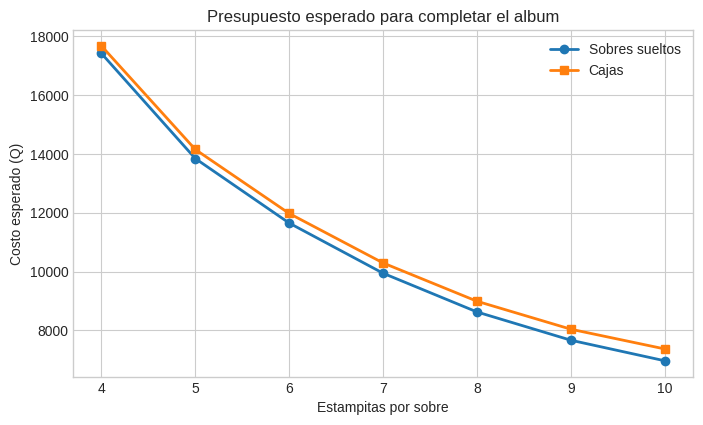

In [7]:
valores_s = [4, 5, 6, 7, 8, 9, 10]
resultados_variacion = []

for s in valores_s:
    sobres_s, _ = simular_hasta_meta(
        n=N,
        s=s,
        r=R_VARIACION,
        seed=SEED + 100 + s,
        fraccion_meta=1.0,
    )

    cajas_s = np.ceil(sobres_s / SOBRES_CAJA)
    media_s = sobres_s.mean()
    resultados_variacion.append(
        {
            "S": s,
            "media_sobres": media_s,
            "costo_sueltos": media_s * PRECIO_SOBRE,
            "costo_cajas": cajas_s.mean() * COSTO_CAJA,
            "teoria": numero_teorico_aproximado(N, s),
        }
    )

filas_q5 = []
for resultado in resultados_variacion:
    filas_q5.append(
        [
            resultado["S"],
            f"{resultado['media_sobres']:,.2f}",
            f"Q {resultado['costo_sueltos']:,.2f}",
            f"Q {resultado['costo_cajas']:,.2f}",
            f"{resultado['teoria']:,.2f}",
        ]
    )

print("Pregunta 5: variacion de presupuesto esperado segun estampitas por sobre")
print("-" * 82)
imprimir_tabla(
    [
        "S",
        "E[sobres]",
        "E[costo sueltos]",
        "E[costo cajas]",
        "Aprox. teorica",
    ],
    filas_q5,
)

s_plot = [r["S"] for r in resultados_variacion]
costo_sueltos_plot = [r["costo_sueltos"] for r in resultados_variacion]
costo_cajas_plot = [r["costo_cajas"] for r in resultados_variacion]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(s_plot, costo_sueltos_plot, marker="o", linewidth=2, label="Sobres sueltos")
ax.plot(s_plot, costo_cajas_plot, marker="s", linewidth=2, label="Cajas")
ax.set_title("Presupuesto esperado para completar el album")
ax.set_xlabel("Estampitas por sobre")
ax.set_ylabel("Costo esperado (Q)")
ax.legend()
plt.show()

### Respuesta 5

El presupuesto esperado baja cuando aumenta el número de estampitas por sobre. En la simulación, pasar de `S = 4` a `S = 10` redujo el costo esperado con sobres sueltos de aproximadamente `Q 17,416.48` a `Q 6,966.16`.

## Conclusión final

Las simulaciones muestran que el tamaño real del álbum cambia mucho la escala del problema. Con pocas estampitas por sobre, completar el álbum exige miles de estampas compradas y una gran cantidad de repetidas. También se observa que un presupuesto de Q `3,000.00` todavía no fue suficiente para completar el álbum real en las simulaciones.

La comparación entre sobres y cajas muestra un intercambio importante: la caja tiene menor precio unitario, pero obliga a comprar en bloques de 104 sobres. Por eso puede generar sobrantes. Finalmente, aumentar las estampitas por sobre es una de las formas más efectivas de reducir el presupuesto esperado, especialmente cuando se pasa de valores bajos como 4 o 5 estampitas por sobre.